# Caso Práctico: Aplicación de Método ARIMA

En este caso práctico veremos como aplicar ARIMA para modelar una serie temporal. La serie temporal corresponde con las ventas mensuales agrergadas de un determinado champú en un supermercado.

Para ello, seguiremos los pasos vistos en la teoría:

1. Calcularemos la autocorrelación para obtener el grado de la componente AR de nuestro modelo de ARIMA
1. Calcularemos la autocorrelación parcial para obtener el grado MA para el modelo de ARIMA
2. Aplicaremos la técnica de diferenciación a la serie temporal.

  3.1. Evaluaremos la estacionariedad de la serie resultante después de la diferenciación para obtener el grado I de nuestro modelo ARIMA.
4. En este punto ya tenemos los parámetros de nuestro modelo ARIMA por lo que podemos ajustarlo.

# Importaión de Datos

In [1]:
import datetime
import pandas as pd
import plotly.express as px

data_path = "shampoo.csv"

df = pd.read_csv(data_path)
months = []

for row in range(df.shape[0]):
    months.append(datetime.datetime.strptime('190'+df['Month'].iloc[row], '%Y-%m'))

df['Fecha'] = months

In [2]:
df['Ventas'] = df['Sales']
df['Tiempo'] = df.index

fig = px.line(df, x=df['Fecha'] ,y=df['Ventas'],
              markers=True,
              labels="fdsf",
              title="Ventas Champú")
fig.show()

# Cálculo de autocorrelaciones




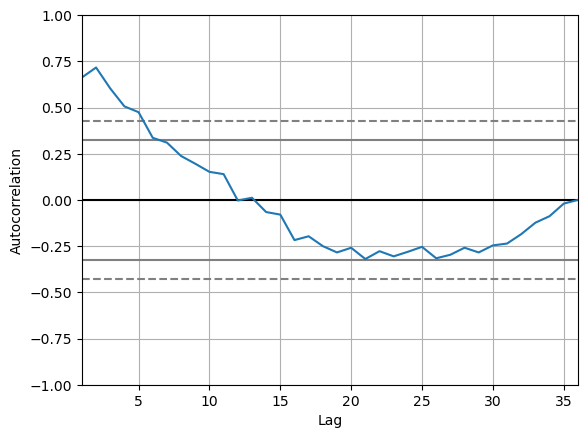

In [3]:
from matplotlib import pyplot

pd.plotting.autocorrelation_plot(df['Sales'])
pyplot.show()

In [4]:
import statsmodels.api as sm
import plotly.graph_objects as go
from plotly.subplots import make_subplots

acorr = sm.tsa.acf(df['Sales'], nlags = 80)
pacorr = sm.tsa.pacf(df['Sales'], nlags=10)

fig = make_subplots(rows=1, cols=1,
                    shared_xaxes=False,
                    shared_yaxes=True,
                    vertical_spacing=0.08,
                    )

fig.add_trace(go.Scatter(y=pacorr, name="Autocorrelación", mode="markers+lines"),
              row=1, col=1)

fig.add_hline(y=0.5, row=1, col=1, line_dash="dash")

fig.update_layout(height=500, width=500,
                  title_text="Autocorrelación Parcial"
                  )

fig['layout']['xaxis1']['title']='Retardo (Intervalos)'
fig.show()

# Aplicación de la diferenciación

## Representación de serie resultante después de aplicar la diferenciación

In [5]:
df['Diferenciación'] = df['Sales'].diff(periods=1)
df['Diferenciación_2'] = df['Diferenciación'].diff(periods=1)
df['Diferenciación_3'] = df['Diferenciación_2'].diff(periods=1)


fig = make_subplots(rows=3, cols=1,
                    shared_xaxes=False,
                    shared_yaxes=True,
                    vertical_spacing=0.08,
                    )

fig.add_trace(go.Scatter(y=df['Diferenciación'], name="Orden 1", mode="markers+lines"),
              row=1, col=1)
fig.add_trace(go.Scatter(y=df['Diferenciación_2'], name="Orden 2", mode="markers+lines"),
              row=2, col=1)

fig.add_trace(go.Scatter(y=df['Diferenciación_3'], name="Orden 3", mode="markers+lines"),
              row=3, col=1)

fig.update_layout(height=500, width=900,
                  title_text="Diferenciación"
                  )
fig['layout']['xaxis1']['title']=''
fig['layout']['xaxis2']['title']=''

fig.show()

## Test estadístico para asumir estacionariedad

In [6]:
from statsmodels.tsa.stattools import adfuller

X = df['Diferenciación'].values
result = adfuller(X[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
 print('\t%s: %.3f' % (key, value))

ADF Statistic: -7.249074
p-value: 0.000000
Critical Values:
	1%: -3.646
	5%: -2.954
	10%: -2.616


In [7]:
X = df['Diferenciación_2'].values
result = adfuller(X[2:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
 print('\t%s: %.3f' % (key, value))

ADF Statistic: -3.715053
p-value: 0.003906
Critical Values:
	1%: -3.753
	5%: -2.998
	10%: -2.639


In [8]:
X = df['Diferenciación_3'].values
result = adfuller(X[3:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
 print('\t%s: %.3f' % (key, value))

ADF Statistic: -5.120548
p-value: 0.000013
Critical Values:
	1%: -3.724
	5%: -2.986
	10%: -2.633


# Aplicación de ARIMA

In [9]:
from pandas import read_csv
from datetime import datetime
from matplotlib import pyplot
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from math import sqrt

"""
Cargamos el conjunto de Datos
"""

def parser(x):
 return datetime.strptime('190'+x, '%Y-%m')
series = read_csv(data_path, header=0, index_col=0,
                  parse_dates=True,
                  date_parser=parser).squeeze("columns")

"""
Ajustamos es índice temporal de los datos
"""
series.index = series.index.to_period('M')

"""
Separamos los datos para obtener un conjunto de entrenamiento
y otro conjunto de test
"""
X = series.values
size = int(len(X) * 0.60)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()

C:\Users\nunoc\AppData\Local\Temp\ipykernel_11784\1368617633.py:14: FutureWarning:

The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.



In [10]:
fig = make_subplots(rows=1, cols=1,
                    shared_xaxes=False,
                    shared_yaxes=True,
                    vertical_spacing=0.08,
                    )
fig.add_trace(go.Scatter(x=df['Fecha'][:-15], y=train, name="Ajuste", mode="markers+lines"),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df['Fecha'][-15:], y=test, name="Test", mode="markers+lines"),
              row=1, col=1)
fig.update_layout(height=500, width=900,
                  title_text="Separación de conjunto de datos"
                  )
fig['layout']['xaxis1']['title']=''
fig['layout']['yaxis1']['title']='Ventas'

fig.show()

In [11]:
"""
Ajuste del modelo ARIMA con los datos de entrenamiento
"""

for t in range(len(test)):
  model = ARIMA(history, order=(5,1,3))
  model_fit = model.fit()
  output = model_fit.forecast()
  yhat = output[0]
  predictions.append(yhat)
  obs = test[t]
  history.append(obs)
  print('predicted=%f, expected=%f' % (yhat, obs))

"""
Calculamos el error que comete el modelo ARIMA para el conjunto de test
"""
rmse = sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)

c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.



predicted=258.475713, expected=421.600000


c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



predicted=270.542100, expected=264.500000
predicted=352.673896, expected=342.300000


c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



...

c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



predicted=456.656043, expected=407.600000


c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



predicted=557.789968, expected=682.000000
predicted=471.093258, expected=475.300000
predicted=667.811610, expected=581.300000
predicted=637.316696, expected=646.900000
Test RMSE: 78.631


c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

c:\Users\nunoc\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



In [12]:
fig = make_subplots(rows=1, cols=1,
                    shared_xaxes=False,
                    shared_yaxes=True,
                    vertical_spacing=0.08,
                    )
fig.add_trace(go.Scatter(x=df['Fecha'][-15:], y=test, name="Valor Real", mode="markers+lines"),
              row=1, col=1)
fig.add_trace(go.Scatter(x=df['Fecha'][-15:], y=predictions, name="Predicción", mode="markers+lines"),
              row=1, col=1)
fig.update_layout(height=500, width=900,
                  title_text="Evaluación"
                  )
fig['layout']['xaxis1']['title']=''
fig['layout']['yaxis1']['title']='Ventas'

fig.show()